# Tandem Accelerator SRIM Compute

Dose calculator for MeV-range tandem accelerator irradiations.
Reads SRIM output files and computes fluence, DPA, at%, and irradiation time.

**Key features:**
- Parses n, DPI, B from SRIM output files (VACANCY.txt, RANGE.txt, E2RECOIL.txt)
- Saturating at% formula: `C/(n+C)×100` (plus dilute-limit for comparison)
- Auto-generates plot titles from SRIM file headers
- Multi-folder comparison tools for energy sweeps and composition studies
- Vacancy + linear fit analysis for flatness characterization
- Triple-axis overlay (DPA + concentration + indenter force)

## Core Functions

In [24]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt

# ==================== PHYSICS ====================

def fluence_layer(dpa, dpi, n_cm3):
    """Fluence [ions/cm^2] needed for a target DPA."""
    return (dpa * n_cm3) / (dpi * 1e8)

def at_percent(B, Fluence, n):
    """
    Saturating (non-dilute) at% at peak implant depth.
      C = B * Fluence   [implanted atoms/cm^3]
      at% = C / (n + C) * 100
    Naturally caps below 100%.
    """
    C = B * Fluence
    return C / (n + C) * 100.0

def at_percent_dilute(B, Fluence, n):
    """
    Dilute-limit at%: (B * Fluence * 100) / n
    Valid when implanted concentration << host density.
    Kept for comparison — use at_percent() for general cases.
    """
    return (B * Fluence * 100) / n

def beam_power_density(current_nA, energy_keV, slit_mm):
    """Beam heating for a square aperture: P = I*V, density = P/area."""
    area_cm2 = (slit_mm / 10.0) ** 2
    power_W = current_nA * 1e-9 * energy_keV * 1e3
    return {
        "Beam power [W]": power_W,
        "Spot area [cm^2]": area_cm2,
        "Power density [W/cm^2]": power_W / area_cm2
    }

def _beam_flux(current_nA, charge_state, slit_mm):
    """Particle flux [ions/(cm^2*s)] for perpendicular square slit."""
    area_cm2 = (slit_mm / 10.0) ** 2
    return (current_nA / area_cm2) * 1e-9 * 6.242e18 / charge_state

def _fmt_hms(seconds):
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = seconds - h*3600 - m*60
    return f"{h}h {m}m {s:.1f}s"

# ==================== SRIM PARSERS ====================

def _read_text(p):
    return Path(p).read_text(encoding="latin-1", errors="ignore")

def parse_srim_metadata(folder):
    """
    Extract ion name, energy, and target composition from SRIM output headers.
    Returns dict: {ion, energy_keV, target_elements, target_label}
    """
    folder = Path(folder)
    for fname in ["VACANCY.txt", "RANGE.txt", "E2RECOIL.txt"]:
        fpath = folder / fname
        if not fpath.exists():
            continue
        text = _read_text(fpath)
        m_ion = re.search(r"Ion\s*=\s*(\w+)\s+Energy\s*=\s*(\d+)\s*keV", text)
        ion = m_ion.group(1) if m_ion else None
        energy = int(m_ion.group(2)) if m_ion else None
        elements = re.findall(r"Layer\s*#\s*\d+-\s*(\w+)\s*=\s*[\d.]+\s+Atomic Percent", text)
        if ion and energy:
            target_label = "".join(elements) if elements else "Target"
            # Format energy string: use MeV if >= 1000 keV
            energy_str = f"{energy/1000:.0f} MeV" if energy >= 1000 else f"{energy} keV"
            return {"ion": ion, "energy_keV": energy, "energy_str": energy_str,
                    "target_elements": elements, "target_label": target_label}
    return {"ion": "Ion", "energy_keV": 0, "energy_str": "0 keV",
            "target_elements": [], "target_label": "Target"}

def parse_atomic_density(e2_path):
    """Read atomic density [atoms/cm^3] from E2RECOIL.txt."""
    m = re.search(r"Density\s*=\s*([0-9.+-Ee]+)\s*atoms/cm3", _read_text(e2_path))
    return float(m.group(1)) if m else None

def parse_DPI_peak(folder):
    """Peak total vacancies (ions+recoils) from VACANCY.txt."""
    p = Path(folder) / "VACANCY.txt"
    mx = None
    data = False
    with p.open(encoding="latin-1", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not data and ("Ang." in s and "IONS" in s and "RECOILS" in s):
                data = True
                next(f, None)
                continue
            if not data:
                continue
            if not s or s[0] in "*;-":
                if mx is not None:
                    break
                continue
            nums = re.findall(r'[-+]?\d+(?:\.\d*)?(?:[EeDd][+-]?\d+)?', s)
            if len(nums) >= 3:
                y = float(nums[1].replace('D','E')) + float(nums[2].replace('D','E'))
                mx = y if mx is None or y > mx else mx
    if mx is None:
        raise ValueError("No data rows found in VACANCY.txt")
    return mx

def parse_B_peak(folder):
    """Peak ion distribution B [1/cm] and depth [angstrom] from RANGE.txt."""
    lines_raw = _read_text(Path(folder) / "RANGE.txt").splitlines(True)
    start = None
    for i, line in enumerate(lines_raw):
        L = line.lower()
        if "ang." in L and "ions" in L and "distribution" in L:
            start = i + 2
            break
    if start is None:
        raise RuntimeError("Could not find distribution table in RANGE.txt")
    df = pd.read_csv(StringIO("".join(lines_raw[start:])),
                     sep=r"\s+", header=None, engine="python")
    df.columns = ["Depth_A", "Ions_Distribution", "Target_Recoils"]
    idx = df["Ions_Distribution"].idxmax()
    return float(df.loc[idx, "Ions_Distribution"]), float(df.loc[idx, "Depth_A"])

def load_srim(folder, override=None):
    """Load n, DPI, B, depth_at_peak from a SRIM output folder."""
    folder = Path(folder)
    n = parse_atomic_density(folder / "E2RECOIL.txt")
    DPI = parse_DPI_peak(folder)
    B, depth_A = parse_B_peak(folder)
    if override:
        n   = override.get("n", n)
        DPI = override.get("DPI", DPI)
        B   = override.get("B", B)
    missing = [k for k, v in {"n": n, "DPI": DPI, "B": B}.items() if v is None]
    if missing:
        raise RuntimeError(f"Missing: {missing}")
    return n, DPI, B, depth_A

## Compute Functions

In [25]:
def compute(folder, dpa_list, current_nA=200.0, charge_state=2.0,
            slit_mm=3.0, energy_keV=None, override=None):
    """
    Compute fluence, at%, and irradiation time for each target DPA.
    Defaults: charge_state=2 (tandem).
    """
    n, DPI, B, depth_A = load_srim(folder, override)
    dpas     = np.asarray(dpa_list, dtype=float)
    fluences = np.array([fluence_layer(d, DPI, n) for d in dpas])
    atpcts   = np.array([at_percent(B, phi, n) for phi in fluences])
    flux     = _beam_flux(current_nA, charge_state, slit_mm)
    times_s  = fluences / flux

    results = pd.DataFrame({
        "DPA": dpas, "Fluence [ions/cm^2]": fluences, "at%": atpcts,
        "Time [s]": times_s, "Time [h:m:s]": [_fmt_hms(t) for t in times_s]
    })
    meta = {"Atomic density [atoms/cm^3]": n, "DPI [displ/ion]": DPI,
            "B peak [1/cm]": B, "Depth at peak [A]": depth_A,
            "Beam current [nA]": current_nA, "Charge state": charge_state,
            "Slit [mm]": slit_mm, "Flux [ions/(cm^2*s)]": flux}
    if energy_keV is not None:
        pwr = beam_power_density(current_nA, energy_keV, slit_mm)
        meta["Beam energy [keV]"] = energy_keV
        meta.update(pwr)
    return results, pd.Series(meta)


def compute_from_time(folder, time_list_s, current_nA=200.0, charge_state=2.0,
                      slit_mm=3.0, energy_keV=None, override=None):
    """
    Given irradiation times [s], compute fluence, DPA, and at%.
    Defaults: charge_state=2 (tandem).
    """
    n, DPI, B, depth_A = load_srim(folder, override)
    flux = _beam_flux(current_nA, charge_state, slit_mm)
    rows = []
    for t in time_list_s:
        t = float(t)
        Phi = flux * t
        dpa = (Phi * DPI * 1e8) / n
        rows.append({"Time [s]": t, "Fluence [ions/cm^2]": Phi,
                     "DPA": dpa, "at%": at_percent(B, Phi, n)})
    meta = {"Atomic density [atoms/cm^3]": n, "DPI [displ/ion]": DPI,
            "B peak [1/cm]": B, "Depth at peak [A]": depth_A,
            "Flux [ions/(cm^2*s)]": flux, "Beam current [nA]": current_nA,
            "Charge state": charge_state, "Slit [mm]": slit_mm}
    if energy_keV is not None:
        pwr = beam_power_density(current_nA, energy_keV, slit_mm)
        meta["Beam energy [keV]"] = energy_keV
        meta.update(pwr)
    return pd.DataFrame(rows), pd.Series(meta)

---
## Tandem Example — DPA → Fluence / Time

In [33]:
results, meta = compute(
    folder="HelionSiC/3MeVSi/",
    dpa_list=[1, 10, 100],
    current_nA=275,
    charge_state=1,
    slit_mm=3,
    energy_keV=3000
)
print(meta.to_string())
print()
print(results.to_string(index=False))


Atomic density [atoms/cm^3]    9.611000e+22
DPI [displ/ion]                5.450752e-01
B peak [1/cm]                  4.350100e+04
Depth at peak [A]              1.520000e+04
Beam current [nA]              2.750000e+02
Charge state                   1.000000e+00
Slit [mm]                      3.000000e+00
Flux [ions/(cm^2*s)]           1.907278e+13
Beam energy [keV]              3.000000e+03
Beam power [W]                 8.250000e-01
Spot area [cm^2]               9.000000e-02
Power density [W/cm^2]         9.166667e+00

  DPA  Fluence [ions/cm^2]      at%    Time [s] Time [h:m:s]
  1.0         1.763243e+15 0.079744   92.448146  0h 1m 32.4s
 10.0         1.763243e+16 0.791755  924.481459 0h 15m 24.5s
100.0         1.763243e+17 7.390887 9244.814593  2h 34m 4.8s


---
## Tandem Example — Time → DPA

In [ ]:
# Example: Gilmer Carbon 11 MeV — Time → DPA, fluence, at%
results_t, meta_t = compute_from_time(
    folder="Gilmer_Carbon/11MeV/",
    time_list_s=[73.9, 739, 7390],
    current_nA=410,
    charge_state=3,
    slit_mm=3
)
print(meta_t.to_string())
print()
print(results_t.to_string(index=False))


---
## Depth Profile Plots (DPA + at%)

In [28]:
def plot_depth_profiles(folder, n_atoms, scale_phi=1e16,
                        tail_frac=0.01, pad_frac=0.05, saturating=False):
    """
    Twin-y plot of DPA and ion at% vs depth.
    Titles auto-generated from SRIM file headers.

    Parameters
    ----------
    folder     : SRIM output folder
    n_atoms    : atomic density [atoms/cm^3]
    scale_phi  : fluence normalization [ions/cm^2]
    tail_frac  : fraction of peak used to auto-trim x-axis
    pad_frac   : extra padding on x-axis beyond tail
    saturating : if True, use saturating at% formula C/(n+C);
                 if False (default), use dilute formula C/n
    """
    meta = parse_srim_metadata(folder)
    ion = meta["ion"]
    energy_str = meta["energy_str"]
    target = meta["target_label"]

    def fnum(x):
        return float(x.replace('D','E'))

    # VACANCY.txt -> DPA
    vac_rows = []
    with open(f"{folder}/VACANCY.txt", "r", encoding="latin-1", errors="ignore") as f:
        for line in f:
            p = line.split()
            if len(p) >= 3:
                try: vac_rows.append((fnum(p[0]), fnum(p[1]), fnum(p[2])))
                except ValueError: continue
    vac = pd.DataFrame(vac_rows, columns=["Depth_A","Vac_Ions","Vac_Recoils"])
    vac["Depth_um"]  = vac["Depth_A"] * 1e-4
    vac["Vac_Total"] = vac["Vac_Ions"] + vac["Vac_Recoils"]
    vac["DPA"]       = scale_phi * vac["Vac_Total"] * 1e8 / n_atoms

    # RANGE.txt -> at%
    rng_rows = []
    with open(f"{folder}/RANGE.txt", "r", encoding="latin-1", errors="ignore") as f:
        for line in f:
            p = line.split()
            if len(p) >= 3:
                try: rng_rows.append((fnum(p[0]), fnum(p[1])))
                except ValueError: continue
    rng = pd.DataFrame(rng_rows, columns=["Depth_A","B_per_cm"])
    rng["Depth_um"] = rng["Depth_A"] * 1e-4
    C = scale_phi * rng["B_per_cm"]
    if saturating:
        rng["atpct"] = C / (n_atoms + C) * 100.0
    else:
        rng["atpct"] = C / n_atoms * 100.0

    # Auto x-range: trim where signal drops below tail_frac of peak
    def tail_x(depth, y):
        ya = np.asarray(y)
        peak = np.nanmax(ya)
        if peak <= 0: return float(depth.max())
        idx = np.where(ya > peak * tail_frac)[0]
        return float(depth.iloc[idx[-1]]) if len(idx) else float(depth.max())

    xmax = max(tail_x(vac["Depth_um"], vac["DPA"]),
               tail_x(rng["Depth_um"], rng["atpct"]))
    xmax = min(xmax * (1 + pad_frac),
               max(vac["Depth_um"].max(), rng["Depth_um"].max()))

    fig, ax1 = plt.subplots(figsize=(9, 5))
    l1, = ax1.plot(vac["Depth_um"], vac["DPA"], lw=2,
                   label=f"DPA per {scale_phi:.0e} ions/cm\u00b2")
    ax1.set_xlabel("Depth (\u00b5m)")
    ax1.set_ylabel(f"DPA per {scale_phi:.0e} ions/cm\u00b2")
    ax1.grid(True)

    ax2 = ax1.twinx()
    l2, = ax2.plot(rng["Depth_um"], rng["atpct"], lw=2, ls="--",
                   label=f"{ion} at% per {scale_phi:.0e} ions/cm\u00b2")
    ax2.set_ylabel(f"{ion} at% per {scale_phi:.0e} ions/cm\u00b2")
    ax1.set_xlim(0, xmax)
    ax1.legend([l1, l2], [l1.get_label(), l2.get_label()], loc="best")
    formula = "saturating" if saturating else "dilute"
    plt.title(f"{energy_str} {ion} \u2192 {target}: DPA and {ion} at% vs Depth ({formula})")
    plt.tight_layout()
    plt.show()
    return vac, rng


In [29]:
def plot_vacancy_profile(folder, title=None):
    """
    Plot vacancy depth profile from VACANCY.txt showing ions, recoils, and total.
    Title auto-generated from SRIM headers if not provided.
    """
    if title is None:
        meta = parse_srim_metadata(folder)
        title = f"{meta['energy_str']} {meta['ion']} \u2192 {meta['target_label']}: Vacancy Production vs Depth"

    rows = []
    with open(f"{folder}/VACANCY.txt", "r", errors="ignore") as f:
        for line in f:
            parts = line.split()
            if len(parts) == 3:
                try: rows.append([float(parts[0]), float(parts[1]), float(parts[2])])
                except ValueError: continue
    df = pd.DataFrame(rows, columns=["Depth_A", "Vac_Ions", "Vac_Recoils"])
    df["Depth_um"] = df["Depth_A"] * 1e-4
    df["Total"] = df["Vac_Ions"] + df["Vac_Recoils"]

    plt.figure(figsize=(10, 6))
    plt.plot(df["Depth_um"], df["Vac_Ions"], label="Vacancies by Ions", lw=2)
    plt.plot(df["Depth_um"], df["Vac_Recoils"], color="gray", label="Vacancies by Recoils", lw=2)
    plt.plot(df["Depth_um"], df["Total"], color="orange", label="Total", lw=2)
    plt.xlabel("Depth (\u00b5m)")
    plt.ylabel("Vacancies / (\u00c5\u00b7Ion)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return df


Atomic density: 9.611e+22 atoms/cm^3


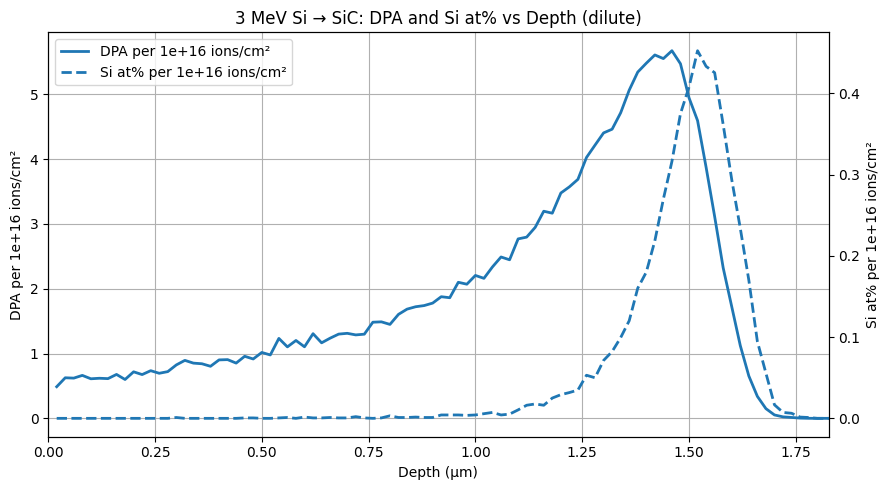

In [31]:
# Example: DPA + at% depth profile for Gilmer 11 MeV Au -> C
FOLDER = "HelionSiC/3MeVSi/"
n_C = parse_atomic_density(Path(FOLDER) / "E2RECOIL.txt")
print(f"Atomic density: {n_C:.3e} atoms/cm^3")
vac, rng = plot_depth_profiles(FOLDER, n_atoms=n_C, scale_phi=1e16)


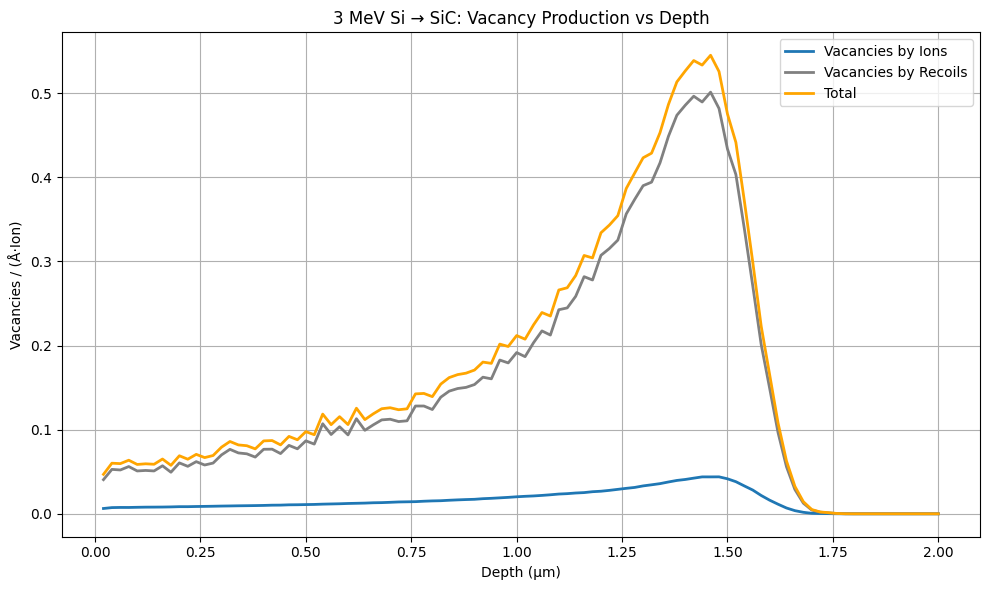

,Depth_A,Vac_Ions,Vac_Recoils,Depth_um,Total
0,200.01,0.006308,0.040577,0.020001,0.046886
1,400.01,0.007365,0.052777,0.040001,0.060142
2,600.01,0.007549,0.052097,0.060001,0.059647
3,800.01,0.007523,0.056163,0.080001,0.063686
4,1000.01,0.007733,0.050928,0.100001,0.058661
...,...,...,...,...,...
95,19200.00,0.000000,0.000000,1.920000,0.000000
96,19400.00,0.000000,0.000000,1.940000,0.000000
97,19600.00,0.000000,0.000000,1.960000,0.000000
98,19800.00,0.000000,0.000000,1.980000,0.000000


In [32]:
# Example: vacancy profile breakdown (ions vs recoils vs total)
plot_vacancy_profile("HelionSiC/3MeVSi/")


---
## Multi-Energy Vacancy Comparison

In [ ]:
def plot_vacancy_multi_energy(base_dir, subfolders, labels=None, title=None,
                              xlim=None, sharey=True, layout="overlay"):
    """
    Compare vacancy profiles across multiple SRIM folders (e.g. different energies).

    Parameters
    ----------
    base_dir   : parent directory containing the subfolders
    subfolders : list of subfolder names, each with a VACANCY.txt
    labels     : display labels (auto-generated from SRIM headers if None)
    title      : plot title (auto-generated if None)
    xlim       : optional (xmin, xmax) in um
    layout     : "overlay" (one plot) or "grid" (subplots)
    """
    base = Path(base_dir)

    def _parse_vac(fpath):
        rows = []
        with open(fpath, "r", errors="ignore") as f:
            for line in f:
                parts = line.split()
                if len(parts) == 3:
                    try: rows.append([float(parts[0]), float(parts[1]), float(parts[2])])
                    except ValueError: continue
        df = pd.DataFrame(rows, columns=["Depth_A", "Vac_Ions", "Vac_Recoils"])
        df["Depth_um"] = df["Depth_A"] * 1e-4
        df["Total"] = df["Vac_Ions"] + df["Vac_Recoils"]
        return df

    datasets = []
    auto_labels = []
    for sub in subfolders:
        folder = base / sub
        vac_path = folder / "VACANCY.txt"
        if not vac_path.exists():
            print(f"[WARN] Missing: {vac_path}")
            continue
        df = _parse_vac(vac_path)
        datasets.append(df)
        meta = parse_srim_metadata(folder)
        auto_labels.append(f"{meta['energy_str']} {meta['ion']}")

    if labels is None:
        labels = auto_labels

    if layout == "overlay":
        plt.figure(figsize=(10, 6))
        for df, lab in zip(datasets, labels):
            plt.plot(df["Depth_um"], df["Total"], lw=2, label=lab)
        if xlim: plt.xlim(*xlim)
        plt.xlabel("Depth (\u00b5m)")
        plt.ylabel("Vacancies / (\u00c5\u00b7Ion)")
        plt.title(title or "Vacancy Production vs Depth")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    elif layout == "grid":
        n = len(datasets)
        cols = min(n, 2)
        rows_n = (n + cols - 1) // cols
        fig, axes = plt.subplots(rows_n, cols, figsize=(6*cols, 4*rows_n),
                                 sharex=True, sharey=sharey, squeeze=False)
        axes_flat = axes.flatten()
        for i, (df, lab) in enumerate(zip(datasets, labels)):
            ax = axes_flat[i]
            ax.plot(df["Depth_um"], df["Total"], lw=2, color="darkorange")
            ax.set_title(lab)
            ax.set_xlabel("Depth (\u00b5m)")
            ax.set_ylabel("Vac / (\u00c5\u00b7Ion)")
            ax.grid(True, alpha=0.3)
            if xlim: ax.set_xlim(*xlim)
        # hide unused
        for j in range(len(datasets), len(axes_flat)):
            axes_flat[j].set_visible(False)
        fig.suptitle(title or "Vacancy Production vs Depth", y=1.01)
        plt.tight_layout()
        plt.show()

    return datasets

---
## Multi-Composition Vacancy Comparison

In [ ]:
def plot_vacancy_multi_composition(base_dir, subfolders, labels=None,
                                    title=None, xlim=None):
    """
    Overlay vacancy profiles for different target compositions on one plot.
    Useful for comparing e.g. YH1.6 vs YH1.7 vs YH2.0 at the same energy.

    Parameters
    ----------
    base_dir   : parent directory containing subfolders
    subfolders : list of subfolder names, each with a VACANCY.txt
    labels     : display labels (default: subfolder names)
    title      : plot title (auto-generated if None)
    xlim       : optional (xmin, xmax) in um
    """
    base = Path(base_dir)

    def _parse_vac(fpath):
        rows = []
        with open(fpath, "r", errors="ignore") as f:
            for line in f:
                parts = line.split()
                if len(parts) == 3:
                    try: rows.append([float(parts[0]), float(parts[1]), float(parts[2])])
                    except ValueError: continue
        df = pd.DataFrame(rows, columns=["Depth_A", "Vac_Ions", "Vac_Recoils"])
        df["Depth_um"] = df["Depth_A"] * 1e-4
        df["Total"] = df["Vac_Ions"] + df["Vac_Recoils"]
        return df

    if labels is None:
        labels = subfolders

    plt.figure(figsize=(10, 6))
    for sub, lab in zip(subfolders, labels):
        vac_path = base / sub / "VACANCY.txt"
        if not vac_path.exists():
            print(f"[WARN] Missing: {vac_path}")
            continue
        df = _parse_vac(vac_path)
        if xlim:
            df = df[df["Depth_um"] <= xlim[1]]
        plt.plot(df["Depth_um"], df["Total"], lw=2, label=lab)

    if xlim: plt.xlim(*xlim)
    plt.xlabel("Depth (\u00b5m)")
    plt.ylabel("Vacancies / (\u00c5\u00b7Ion)")
    plt.title(title or "Vacancy Production vs Depth — Composition Comparison")
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# Example: compare YH compositions at the same energy
plot_vacancy_multi_composition(
    base_dir="HenrySRIM/",
    subfolders=["YH1.6", "YH1.7", "YH1.8", "YH2.0"],
    labels=[r"YH$_{1.59}$", r"YH$_{1.7}$", r"YH$_{1.8}$", r"YH$_{2.0}$"],
    title=r"SRIM Vacancy Production vs Depth for YH$_x$ Targets",
    xlim=(0, 3.5)
)

---
## Vacancy Profile with Linear Fit

In [ ]:
def plot_vacancy_with_fit(folder, band=(1.0, 2.0), title=None):
    """
    Plot vacancy profile with a linear fit in a specified depth band.
    Useful for characterizing flatness of the damage plateau.

    Parameters
    ----------
    folder : SRIM output folder with VACANCY.txt
    band   : (lo, hi) in um — region for linear fit
    title  : plot title (auto-generated if None)
    """
    meta = parse_srim_metadata(folder)
    if title is None:
        title = f"{meta['energy_str']} {meta['ion']} \u2192 {meta['target_label']}: Vacancy + Fit"

    rows = []
    with open(f"{folder}/VACANCY.txt", "r", errors="ignore") as f:
        for line in f:
            parts = line.split()
            if len(parts) == 3:
                try: rows.append([float(parts[0]), float(parts[1]), float(parts[2])])
                except ValueError: continue
    df = pd.DataFrame(rows, columns=["Depth_A", "Vac_Ions", "Vac_Recoils"])
    df["Depth_um"] = df["Depth_A"] * 1e-4
    df["Total"] = df["Vac_Ions"] + df["Vac_Recoils"]

    lo, hi = band
    window = df[(df["Depth_um"] >= lo) & (df["Depth_um"] <= hi)]

    plt.figure(figsize=(12, 6))
    plt.plot(df["Depth_um"], df["Total"], lw=2, color="darkorange",
             label=meta['energy_str'])

    if len(window) >= 2:
        m, b = np.polyfit(window["Depth_um"], window["Total"], 1)
        x_fit = np.linspace(lo, hi, 200)
        y_fit = m * x_fit + b
        plt.plot(x_fit, y_fit, "k--", lw=2)

        # R^2
        yhat = m * window["Depth_um"] + b
        ss_res = np.sum((window["Total"] - yhat) ** 2)
        ss_tot = np.sum((window["Total"] - window["Total"].mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        eq_text = f"y = {m:.3f}\u00b7x + {b:.3f}\nR\u00b2 = {r2:.4f}"
        plt.text(lo + 0.05, max(y_fit) * 0.95, eq_text, fontsize=12,
                 bbox=dict(facecolor="white", alpha=0.8))
        print(f"[{title}] Slope: {m:.3e}  R\u00b2: {r2:.4f}")

    plt.axvspan(lo, hi, alpha=0.1, color="gray", label=f"{lo}\u2013{hi} \u00b5m region")
    plt.xlabel("Depth (\u00b5m)")
    plt.ylabel("Vacancies / (\u00c5\u00b7Ion)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return df

In [ ]:
# Example: C18150 14 MeV vacancy profile with linear fit in 1-2 um band
plot_vacancy_with_fit("C18150/14MEV/", band=(1.0, 2.0))

---
## Triple-Axis Plot (DPA + Concentration + Indenter Force)

In [ ]:
def plot_triple_axis(folder, n_atoms, scale_phi=1e16,
                     indent_zones=None, force_data=None, title=None):
    """
    Triple-axis plot: DPA (left), ion concentration at% (right inner),
    and optional indenter force (right outer).

    Parameters
    ----------
    folder     : SRIM output folder
    n_atoms    : atomic density [atoms/cm^3]
    scale_phi  : fluence normalization [ions/cm^2]
    indent_zones : optional dict with 'plastic': (lo, hi) and/or 'hardness': (lo, hi) in um
    force_data : optional (depth_um_array, force_uN_array) for indenter force overlay
    title      : plot title (auto-generated if None)
    """
    meta = parse_srim_metadata(folder)
    ion = meta["ion"]
    energy_str = meta["energy_str"]
    target = meta["target_label"]
    if title is None:
        title = f"{energy_str} {ion} \u2192 {target}: DPA, {ion} at%, and Indenter Force"

    def fnum(x):
        return float(x.replace('D','E'))

    # VACANCY.txt -> DPA
    vac_rows = []
    with open(f"{folder}/VACANCY.txt", "r", encoding="latin-1", errors="ignore") as f:
        for line in f:
            p = line.split()
            if len(p) >= 3:
                try: vac_rows.append((fnum(p[0]), fnum(p[1]), fnum(p[2])))
                except ValueError: continue
    vac = pd.DataFrame(vac_rows, columns=["Depth_A", "Vac_Ions", "Vac_Recoils"])
    vac["Depth_um"] = vac["Depth_A"] * 1e-4
    vac["Vac_Total"] = vac["Vac_Ions"] + vac["Vac_Recoils"]
    vac["DPA"] = scale_phi * vac["Vac_Total"] * 1e8 / n_atoms

    # RANGE.txt -> at%
    rng_rows = []
    with open(f"{folder}/RANGE.txt", "r", encoding="latin-1", errors="ignore") as f:
        for line in f:
            p = line.split()
            if len(p) >= 3:
                try: rng_rows.append((fnum(p[0]), fnum(p[1])))
                except ValueError: continue
    rng = pd.DataFrame(rng_rows, columns=["Depth_A", "B_per_cm"])
    rng["Depth_um"] = rng["Depth_A"] * 1e-4
    # Use dilute formula for tandem (concentrations are low)
    rng["atpct"] = 100.0 * scale_phi * rng["B_per_cm"] / n_atoms

    # Colors
    C_DPA = "#1f77b4"
    C_ION = "#ff7f0e"
    C_FORCE = "#2ca02c"

    fig, ax_dpa = plt.subplots(figsize=(12, 6))
    ax_ion = ax_dpa.twinx()

    l1, = ax_dpa.plot(vac["Depth_um"], vac["DPA"], lw=2, color=C_DPA, label="DPA")
    l2, = ax_ion.plot(rng["Depth_um"], rng["atpct"], lw=2, color=C_ION,
                      label=f"{ion} Concentration")

    handles = [l1, l2]

    # Optional force axis
    if force_data is not None:
        ax_force = ax_dpa.twinx()
        ax_force.spines["right"].set_position(("axes", 1.12))
        ax_force.set_frame_on(True)
        ax_force.patch.set_visible(False)
        depth_f, force_f = force_data
        l3, = ax_force.plot(depth_f, force_f, lw=2, color=C_FORCE, label="Indenter Force")
        ax_force.set_ylabel("Force (\u00b5N)", color=C_FORCE)
        ax_force.tick_params(axis="y", colors=C_FORCE)
        handles.append(l3)

    # Optional indent zones
    if indent_zones:
        if "plastic" in indent_zones:
            lo, hi = indent_zones["plastic"]
            h = ax_dpa.axvspan(lo, hi, alpha=0.15, color="#f4e4d6",
                               label="Indent Plastic Zone")
            handles.append(h)
        if "hardness" in indent_zones:
            lo, hi = indent_zones["hardness"]
            h = ax_dpa.axvspan(lo, hi, alpha=0.25, color="#e58ad2",
                               label="Avg Hardness Region")
            handles.append(h)

    ax_dpa.set_xlabel("Depth (\u00b5m)")
    ax_dpa.set_ylabel("DPA", color=C_DPA)
    ax_ion.set_ylabel(f"{ion} Concentration (at%)", color=C_ION)
    ax_dpa.tick_params(axis="y", colors=C_DPA)
    ax_ion.tick_params(axis="y", colors=C_ION)

    ax_dpa.legend(handles, [h.get_label() for h in handles], loc="lower right")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return vac, rng

In [ ]:
# Example: Steven 5 MeV Ti into C18150 with nanoindentation overlay
FOLDER = "Steven_5MeV_Ti_S/"
N_ATOMS = 8.582e22    # C18150 atomic density

# Placeholder indenter force (replace with real data if available)
depth_f = np.linspace(0, 2.5, 200)
force_f = 20000.0 * (1.0 - np.exp(-depth_f / 0.35))

vac, rng = plot_triple_axis(
    folder=FOLDER,
    n_atoms=N_ATOMS,
    scale_phi=1e16,
    indent_zones={"plastic": (0.0, 1.55), "hardness": (0.25, 0.40)},
    force_data=(depth_f, force_f)
)